# Пример реализации GWO

In [4]:
import osmnx as ox
import matplotlib.pyplot as plt

from genesis.states import FirstArrivalUnitState
from genesis.best_points import BestNodeGWO
from graphs.algorithms import generate_grid_graph
from fire_units.metrics import ArrivalTime

# 1. Загрузка исходных данных
G = generate_grid_graph(n=100, m=100, step=100.0, speed=20, diagonals=True)

# 2. Сборка решения
state = FirstArrivalUnitState()
metric = ArrivalTime()
gwo = BestNodeGWO(
    state_function = state,
    metric_function = metric,
    max_iter = 30,
    pack_size = 30,
    hunt_bound = 0.5,
    consensus_value = 0.75,
    iteration_end_function = lambda value, iteration, **kwargs: print(iteration, round(value, 2))
)

# 3. Запуск алгоритма
best_nodes_gwo, best_metric_gwo = gwo(
    env = G,
    area = None,
    start_point = None,
    points_list = None,
)



13.34
13.21
13.11
13.08
13.08
13.08
13.08
13.08
13.07
13.07
13.07
13.07
13.07
13.07
13.07
13.07
13.07


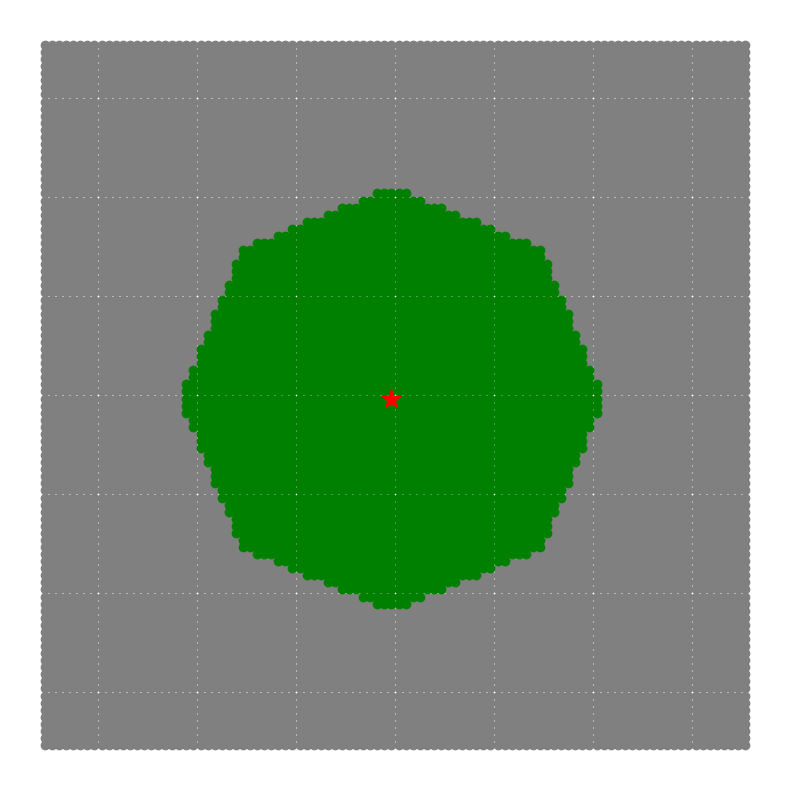

In [ ]:
# 4. Анализ результатов
g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
times, _ = FirstArrivalUnitState()(G, [best_nodes_gwo])
g_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
g_nodes['arrival_time'] = times


fig, ax = plt.subplots(figsize=(10, 10))
# Визуализация графа
g_nodes.plot(ax=ax, color='grey')
g_nodes.query('arrival_time < 10').plot(ax=ax, color='green')
g_nodes.iloc[[best_nodes_gwo]].plot(ax=ax, color='red', markersize=200, marker='*')
ax.axis('off')

plt.show()